# F0 (pitch contour) transfer between Kokoro voices

**Idea:** the *shape* of the F0 contour comes from the **pitch donor** voice, the *register* (mean / range) stays the **target** voice's.

1. Fix one set of durations, so both contours are frame-aligned.
2. Predict F0 for the donor and for the target with those durations.
3. Normalize in log-F0 (semitone) space on voiced frames:
   `logF0_new = (logF0_donor − μ_donor) / σ_donor · σ_target + μ_target`
4. Decode the target voice (timbre + its own energy) with the new F0.

In [1]:
from functions import * 
from functions import  _voice_pack, _encode,   predict_durations   , align_phonemes   # model, g2p, _encode, _voice_pack, predict_durations, align_phonemes, SR, FRAME_SAMPLES
import torch, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Audio

c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(
c:\Users\utente\anaconda3\envs\koko\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [2]:
@torch.no_grad()
def make_alignment(ps, dur):
    """Token-to-frame alignment matrix (n_tokens x n_frames) from durations."""
    dev = model.device
    n = _encode(ps)["n"]
    dur = torch.as_tensor(dur, device=dev).long().clamp(min=0).reshape(-1)
    assert dur.shape[0] == n, f"durations ({dur.shape[0]}) != tokens incl. BOS/EOS ({n})"
    idx = torch.repeat_interleave(torch.arange(n, device=dev), dur)
    aln = torch.zeros((n, idx.shape[0]), device=dev)
    aln[idx, torch.arange(idx.shape[0], device=dev)] = 1
    return aln.unsqueeze(0)


@torch.no_grad()
def predict_f0n(ps, pack, aln):
    """Kokoro's predicted F0 (Hz) and energy N for voice `pack`, on the given alignment."""
    enc = _encode(ps)
    s = pack[len(ps) - 1][:, 128:]
    d = model.predictor.text_encoder(enc["d_en"], s, enc["L"], enc["tm"])
    F0, N = model.predictor.F0Ntrain(d.transpose(-1, -2) @ aln, s)
    return F0, N                     # shape (1, 2*n_frames): F0 runs at 2x the duration frame rate


@torch.no_grad()
def decode(ps, pack, aln, F0, N):
    """Run the decoder with voice `pack`'s timbre and the GIVEN F0 / energy curves."""
    enc = _encode(ps)
    ref_s = pack[len(ps) - 1]
    return model.decoder(enc["t_en"] @ aln, F0, N, ref_s[:, :128]).squeeze().cpu().numpy()

In [3]:
VOICED_HZ = 50.0   # frames below this count as unvoiced (Kokoro's source treats F0 < ~10 Hz as unvoiced)

def f0_stats(f0, thr=VOICED_HZ):
    v = f0[f0 > thr]
    lf = np.log(v)
    return lf.mean(), lf.std(), np.exp(lf.mean())


def normalize_f0(f0_donor, f0_target, mode="meanstd", thr=VOICED_HZ):
    """Put the donor's contour shape into the target's register (log domain).
    mode = "mean"    -> shift only (keeps the donor's pitch range in semitones)
           "meanstd" -> shift + rescale range to the target's
    Unvoiced frames keep the donor's values, so voicing follows the donor contour."""
    mu_d, sd_d, _ = f0_stats(f0_donor, thr)
    mu_t, sd_t, _ = f0_stats(f0_target, thr)
    out = f0_donor.copy()
    v = f0_donor > thr
    z = np.log(f0_donor[v]) - mu_d
    if mode == "meanstd":
        z = z / sd_d * sd_t
    out[v] = np.exp(z + mu_t)
    return out

## Settings

In [8]:
text = """Il gatto dorme sotto il ramo verde;Maria compra il pane fresco ogni mattina; Il treno parte alle otto di sera; Mio fratello studia la storia a Roma.
La porta grande della cucina è aperta; Oggi il mare è calmo e chiaro vicino alla riva.
Abbiamo comprato tre libri nuovi; Il bambino gioca con la sorella nel parco dopo pranzo.
Domani andremo al mercato in centro; Stasera leggo un romanzo storico."""

target_voice = "im_nicola"   # timbre + register of the output
donor_voice  = "jf_alpha"     # where the F0 contour SHAPE comes from
dur_voice    = target_voice  # whose durations drive the timing (could also be the donor)
mode         = "meanstd"     # "mean" or "meanstd"

ps = text_to_ipa_chunks(text)[0]           # one sentence for simplicity
print(ps)

il ɡˈatːo dˈɔrme sˈotːo il rˈamo vˈerde;mˌarˈiːa kˈompra il pˈane frˈesko ˌoɲɲɪ matːˈina; il trˈɛno pˈarte ˌalle ˈɔtːo dɪ sˈera; mˌio fratˈɛllo stˈudia la stˈɔria a rˈoma.


## Transfer

In [9]:
tpack, _ = _voice_pack(target_voice)
dpack, _ = _voice_pack(donor_voice)
upack, _ = _voice_pack(dur_voice)

dur = predict_durations(ps, upack)          # shared durations -> contours are frame-aligned
aln = make_alignment(ps, dur)

F0_t, N_t = predict_f0n(ps, tpack, aln)     # target's own pitch
F0_d, N_d = predict_f0n(ps, dpack, aln)     # donor's pitch

f0_t = F0_t.squeeze().cpu().numpy()
f0_d = F0_d.squeeze().cpu().numpy()
f0_new = normalize_f0(f0_d, f0_t, mode=mode)
F0_new = torch.tensor(f0_new, dtype=F0_t.dtype, device=F0_t.device).unsqueeze(0)

audio_target = decode(ps, tpack, aln, F0_t,   N_t)   # target as usual
audio_donor  = decode(ps, dpack, aln, F0_d,   N_d)   # donor as usual (same timing)
audio_new    = decode(ps, tpack, aln, F0_new, N_t)   # target timbre + donor contour

for name, f in [("target", f0_t), ("donor", f0_d), ("transferred", f0_new)]:
    mu, sd, hz = f0_stats(f)
    print(f"{name:12s} mean {hz:6.1f} Hz   std {sd*12/np.log(2):4.1f} semitones")
print(f"shift applied: {12*np.log2(f0_stats(f0_t)[2]/f0_stats(f0_d)[2]):+.1f} semitones")

target       mean   89.9 Hz   std  3.1 semitones
donor        mean  247.6 Hz   std  3.7 semitones
transferred  mean   90.7 Hz   std  2.6 semitones
shift applied: -17.5 semitones


In [10]:
print("target (own pitch)");          display(Audio(audio_target, rate=SR))
print("donor");                       display(Audio(audio_donor,  rate=SR))
print("target with donor F0 contour"); display(Audio(audio_new,    rate=SR))

target (own pitch)


donor


target with donor F0 contour


## Visualize

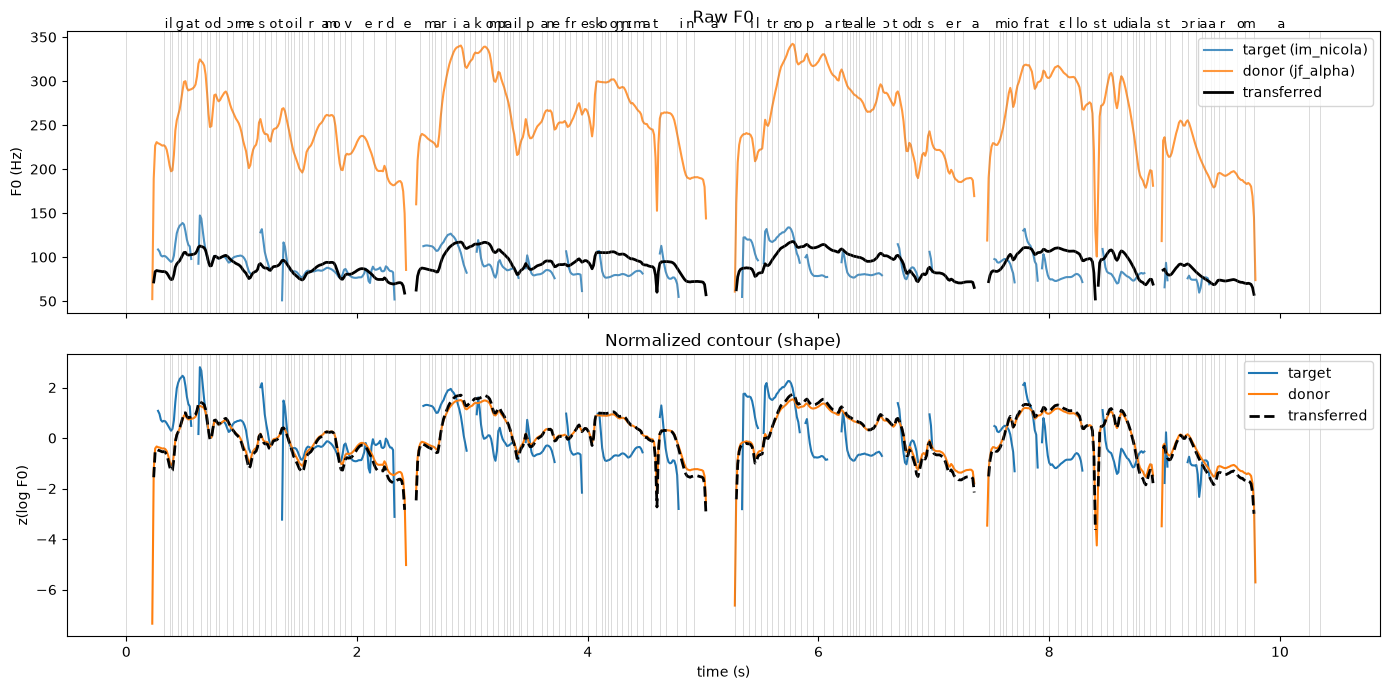

In [11]:
def masked(f, thr=VOICED_HZ):
    f = f.copy(); f[f <= thr] = np.nan   # hide unvoiced frames
    return f

t = np.arange(len(f0_t)) * (FRAME_SAMPLES / 2) / SR          # F0 frame = half a duration frame
segs, _, _ = align_phonemes(ps, dur, n_samples=len(audio_new))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(t, masked(f0_t),   label=f"target ({target_voice})", alpha=.8)
ax.plot(t, masked(f0_d),   label=f"donor ({donor_voice})", alpha=.8)
ax.plot(t, masked(f0_new), label="transferred", lw=2, color="k")
ax.set_ylabel("F0 (Hz)"); ax.set_title("Raw F0"); ax.legend()

ax = axes[1]   # z-scored log F0: shows the SHAPE only, register removed
for f, lab, kw in [(f0_t, "target", {}), (f0_d, "donor", {}), (f0_new, "transferred", {"lw": 2, "color": "k", "ls": "--"})]:
    mu, sd, _ = f0_stats(f)
    ax.plot(t, (np.log(masked(f)) - mu) / sd, label=lab, **kw)
ax.set_ylabel("z(log F0)"); ax.set_title("Normalized contour (shape)"); ax.legend()
ax.set_xlabel("time (s)")

for ax in axes:                                              # phoneme boundaries + labels
    for lab, s, e, info in segs:
        ax.axvline(s, color="gray", lw=.4, alpha=.5)
for lab, s, e, info in segs:
    if info["kind"] == "phone":
        axes[0].text((s + e) / 2, axes[0].get_ylim()[1], lab, ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## (Optional) check the pitch actually present in the output audio

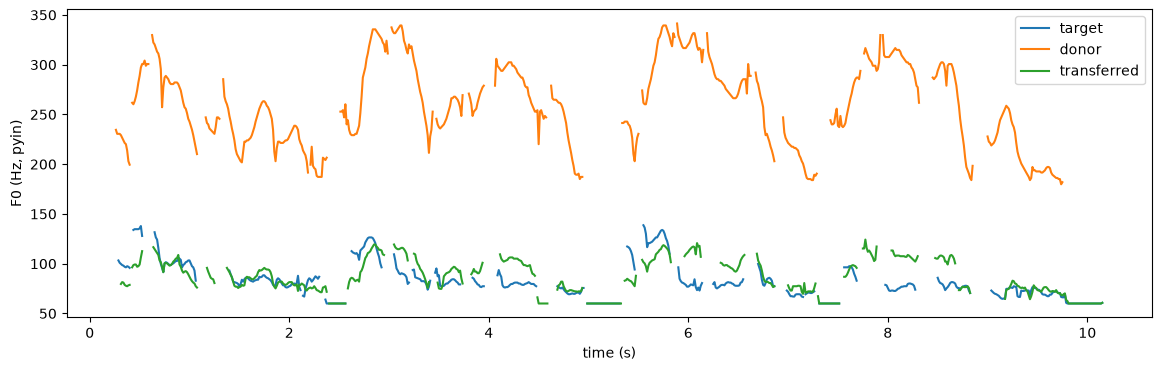

In [13]:
import librosa   # pip install librosa
fig, ax = plt.subplots(figsize=(14, 4))
for a, lab in [(audio_target, "target"), (audio_donor, "donor"), (audio_new, "transferred")]:
    f, _, _ = librosa.pyin(a, fmin=60, fmax=500, sr=SR, frame_length=1024, hop_length=300)
    ax.plot(np.arange(len(f)) * 300 / SR, f, label=lab)
ax.set_ylabel("F0 (Hz, pyin)"); ax.set_xlabel("time (s)"); ax.legend(); plt.show()